# Employee Attrition Prediction Using Machine Learning

### CodTech Data Analysis Internship - Task 2

#### Objective
The objective of this project is to develop a machine learning model that predicts employee attrition using the IBM HR Analytics dataset. The project includes data exploration, feature selection, data preprocessing, model training, evaluation, and business insights generation.

#### Tools & Technologies Used
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [2]:
#Import Libraries
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load Dataset

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Data Exploration
# Dataset Shape

print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (1470, 35)

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
# Missing Values

df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


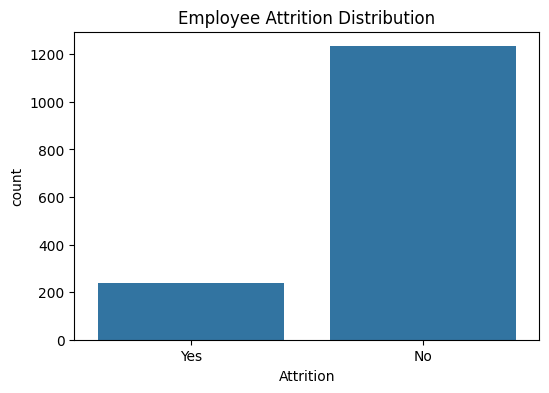

In [7]:
# EDA Graphs
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)

plt.title('Employee Attrition Distribution')
plt.show()

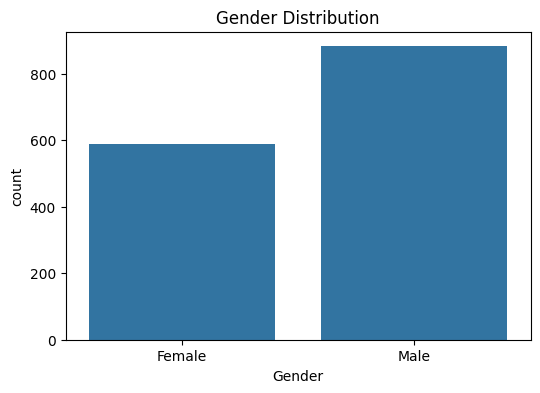

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')
plt.show()

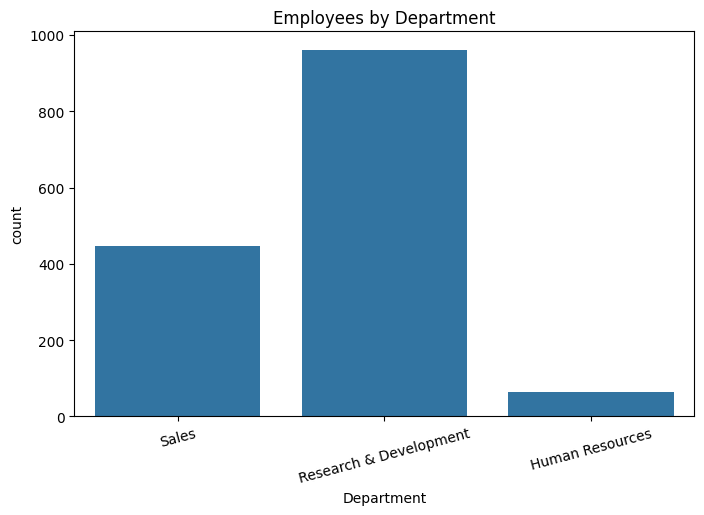

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', data=df)

plt.title('Employees by Department')
plt.xticks(rotation=15)
plt.show()

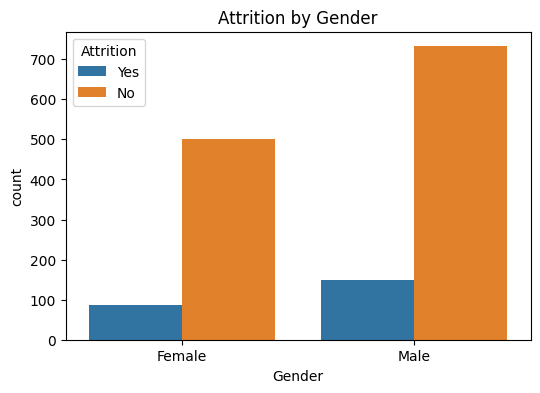

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Attrition', data=df)

plt.title('Attrition by Gender')
plt.show()

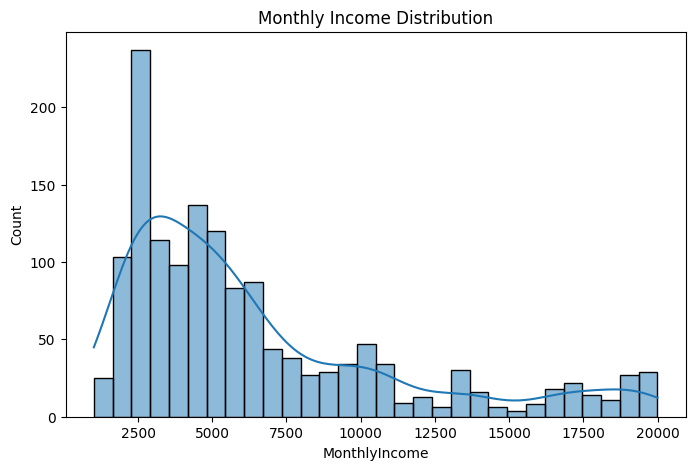

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True)

plt.title('Monthly Income Distribution')
plt.show()

In [12]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [13]:
# Data Preprocessing
# Remove columns with no predictive value

df = df.drop([
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
], axis=1)

print(df.shape)

(1470, 31)


In [14]:
# Convert Attrition to numeric

df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

df['Attrition'].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [16]:
# Features and Target

X = df.drop('Attrition', axis=1)

y = df['Attrition']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 30)
Target Shape: (1470,)


In [17]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 30)
Testing Data: (294, 30)


In [18]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy: 87.76 %


In [19]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2), "%")

Decision Tree Accuracy: 79.93 %


In [20]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

Random Forest Accuracy: 88.1 %


In [21]:
# Model Comparision
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy (%)': [
        lr_accuracy*100,
        dt_accuracy*100,
        rf_accuracy*100
    ]
})

results.sort_values(
    by='Accuracy (%)',
    ascending=False
)

,Model,Accuracy (%)
2,Random Forest,88.095238
0,Logistic Regression,87.755102
1,Decision Tree,79.931973


In [22]:
# Classification Report
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



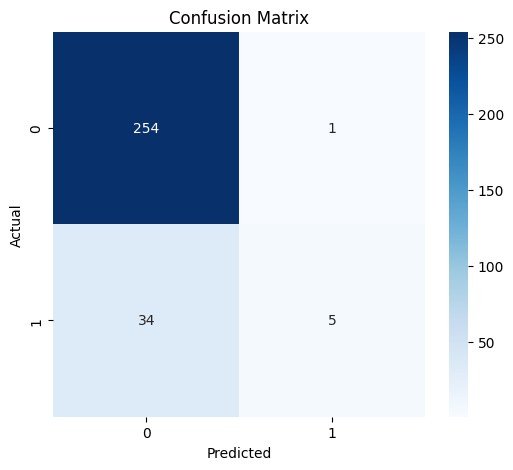

In [23]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
15,MonthlyIncome,0.078212
18,OverTime,0.066669
0,Age,0.061569
2,DailyRate,0.054087
23,TotalWorkingYears,0.052491
16,MonthlyRate,0.048373
9,HourlyRate,0.047369
4,DistanceFromHome,0.045999
26,YearsAtCompany,0.041347
17,NumCompaniesWorked,0.037951


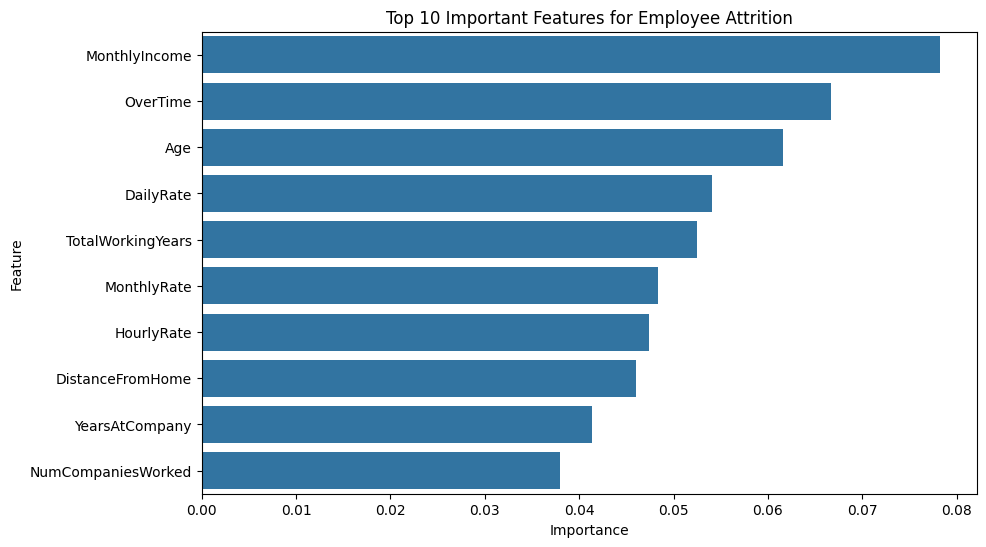

In [25]:
# Feature Importance graph
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Important Features for Employee Attrition')
plt.show()

## Business Insights

1. The dataset contained 1,470 employee records and 35 features.

2. No missing values were found, indicating a clean dataset.

3. Research & Development was the largest department.

4. Employee attrition was significantly lower than employee retention.

5. Three machine learning models were evaluated:
   - Logistic Regression: 87.76%
   - Decision Tree: 79.93%
   - Random Forest: 88.10%

6. Random Forest achieved the highest accuracy and was selected as the final model.

7. The most important features influencing attrition were identified using feature importance analysis.

8. This model can help organizations identify employees at risk of leaving and take proactive retention measures.

## Conclusion

This project successfully developed a machine learning model to predict employee attrition using the IBM HR Analytics dataset.

After preprocessing, feature selection, and model training, Random Forest achieved the highest accuracy of 88.10%.

The analysis demonstrates how machine learning can support HR departments in predicting employee turnover and improving workforce retention strategies.